In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score,classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
import seaborn as sns

In [2]:
data = {
    "Age": [
        22,25,47,52,46,56,23,27,39,41,
        30,28,35,48,50,33,29,42,37,31
    ],
    
    "Income": [
        15000,18000,52000,110000,75000,120000,20000,22000,58000,62000,
        30000,27000,45000,90000,100000,40000,32000,65000,70000,35000
    ],
    
    "Student": [
        "Yes","Yes","No","No","No","No","Yes","Yes","No","No",
        "Yes","Yes","No","No","No","Yes","Yes","No","No","Yes"
    ],
    
    "Credit_Rating": [
        "Fair","Fair","Excellent","Fair","Excellent","Excellent","Fair","Excellent","Fair","Excellent",
        "Fair","Fair","Excellent","Excellent","Fair","Fair","Excellent","Excellent","Fair","Fair"
    ],
    
    "Spending_Score": [
        39,81,6,77,40,76,94,3,72,14,
        99,15,55,35,60,85,20,75,50,95
    ],
    
    "Buys_Product": [
        "No","Yes","Yes","Yes","No","Yes","Yes","No","Yes","No",
        "Yes","No","Yes","Yes","Yes","Yes","No","Yes","Yes","Yes"
    ]
}

In [3]:
df=pd.DataFrame(data)

In [4]:
X=df.drop("Buys_Product",axis=1)
y=df["Buys_Product"]

In [5]:
X=pd.get_dummies(X)

In [6]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=42)

In [7]:
scaler=StandardScaler()

In [8]:
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [9]:
nave_reg=GaussianNB()

In [10]:
param={
    'var_smoothing': [1e-9, 1e-8, 1e-7]
}

In [11]:
navcv=GridSearchCV(nave_reg,param_grid=param,scoring="accuracy",cv=5)
navcv.fit(X_train,y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",GaussianNB()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'var_smoothing': [1e-09, 1e-08, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and candidate parame

In [12]:
nav_pre=navcv.predict(X_test)

In [13]:
nav_pre

array(['Yes', 'Yes', 'Yes', 'Yes', 'Yes'], dtype='<U3')

In [14]:
socre=accuracy_score(y_test,nav_pre)

In [15]:
socre

0.8

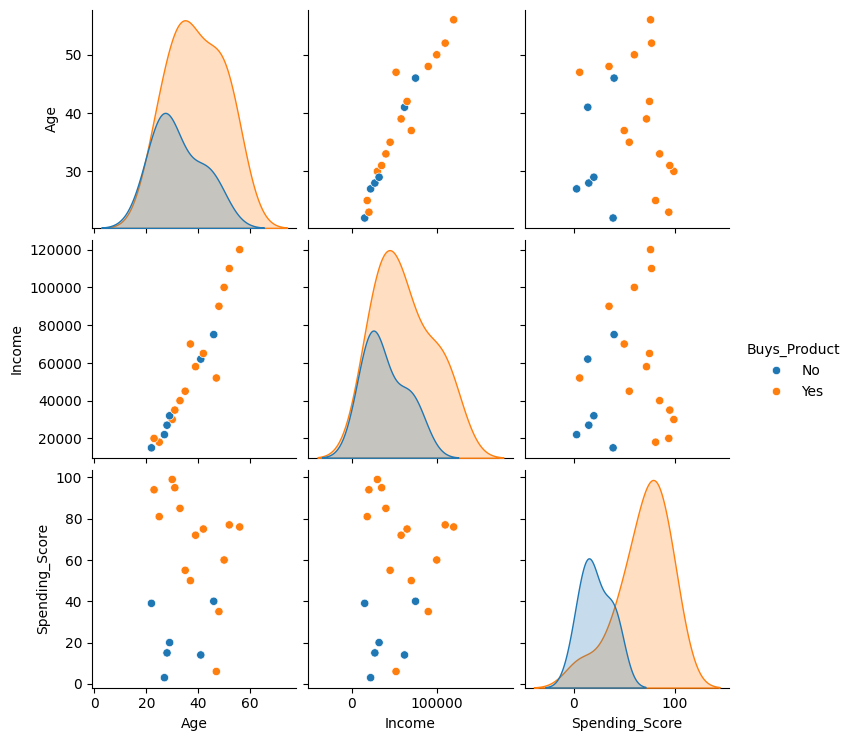

In [16]:
sns.pairplot(df, hue="Buys_Product")
plt.show()

In [17]:
print(classification_report(nav_pre,y_test))

              precision    recall  f1-score   support

          No       0.00      0.00      0.00         0
         Yes       1.00      0.80      0.89         5

    accuracy                           0.80         5
   macro avg       0.50      0.40      0.44         5
weighted avg       1.00      0.80      0.89         5



C:\Users\ADMIN\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\ADMIN\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\ADMIN\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metri